In [2]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [3]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
features = ["pclass","sex","age","fare","embarked"]
target = ["survived"]

In [5]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
#handling missing values
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_most_f = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_most_f.fit_transform(titanic[["embarked"]])

In [7]:
#encoding
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [8]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
X = titanic[features]
y = titanic[target]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size = 0.2, random_state=42)

In [11]:
X_train.head()

,pclass,sex,age,fare,embarked
331,1,1,45.5,28.5000,2
733,2,1,23.0,13.0000,2
382,3,1,32.0,7.9250,2
704,3,1,26.0,7.8542,2
813,3,0,6.0,31.2750,2


In [12]:
# Decision Tree - without pruning
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy: ",accuracy_score(y_test, y_pred))

Accuracy:  0.770949720670391


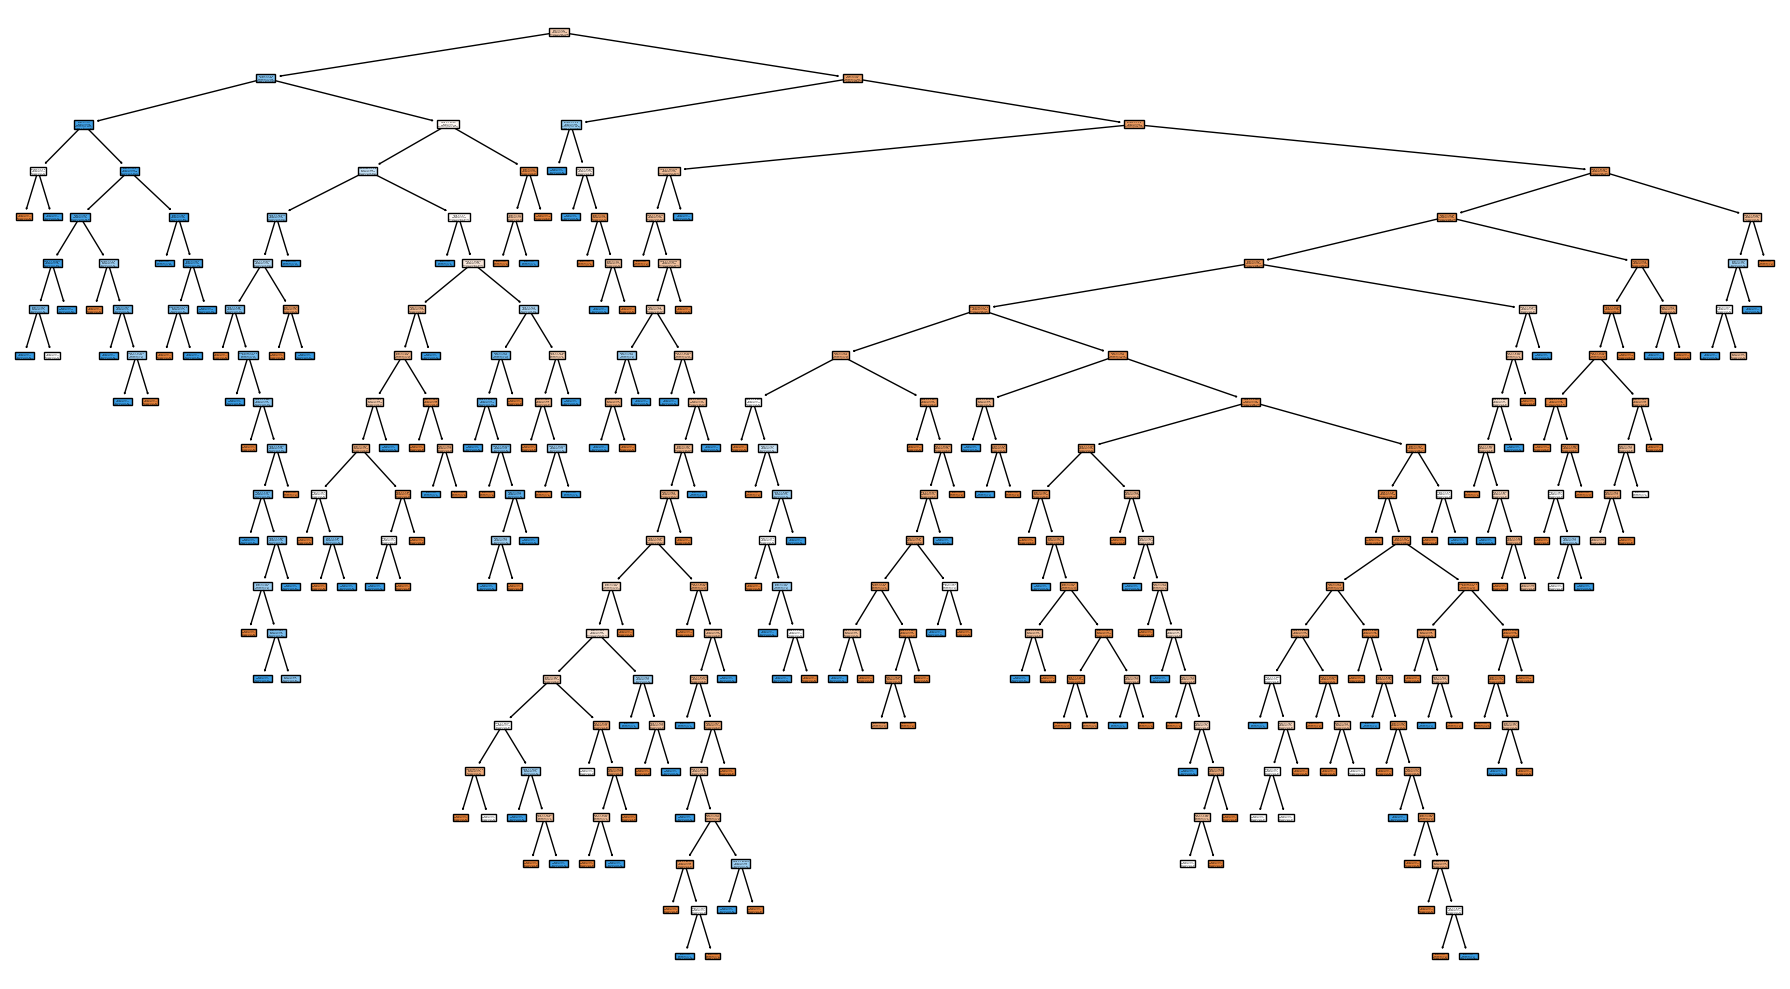

In [13]:
# plt tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survivied"],
    filled = True,
)

plt.tight_layout()
plt.show()

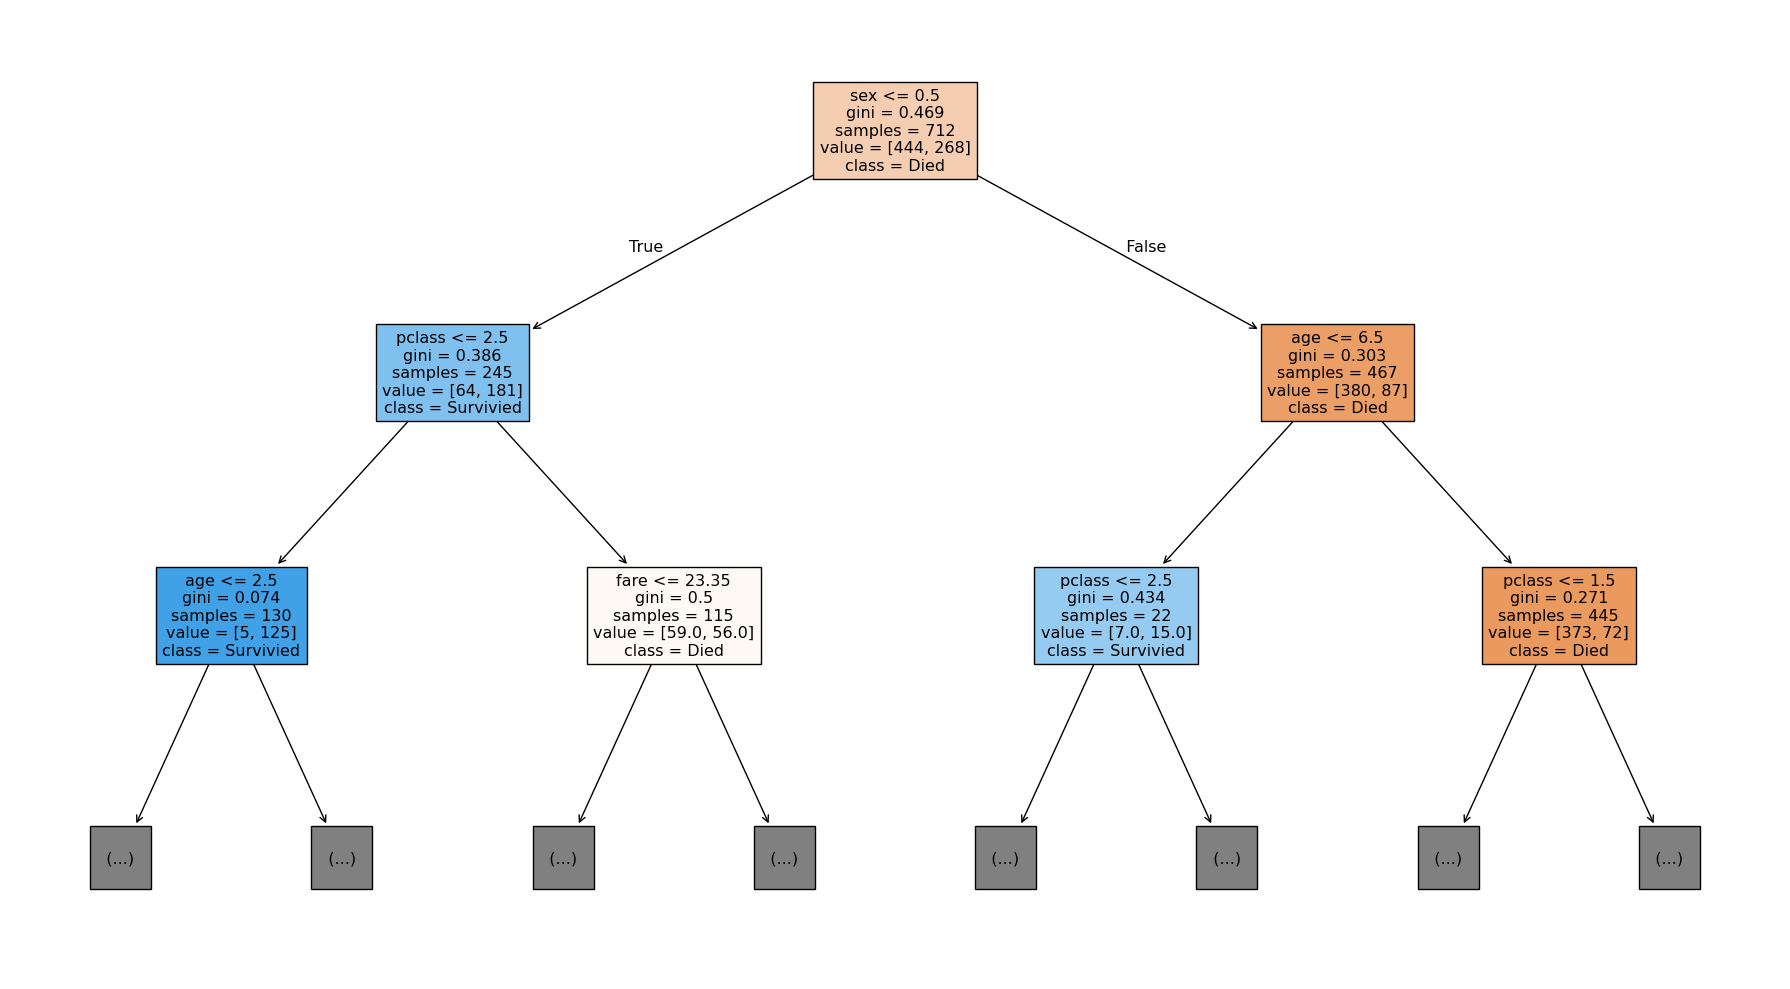

In [14]:
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survivied"],
    filled = True,
    max_depth=2
)

plt.tight_layout()
plt.show()

for depth:2  Accuracy:0.7653631284916201
for depth:3  Accuracy:0.7988826815642458
for depth:4  Accuracy:0.7988826815642458
for depth:5  Accuracy:0.7988826815642458
for depth:6  Accuracy:0.7988826815642458


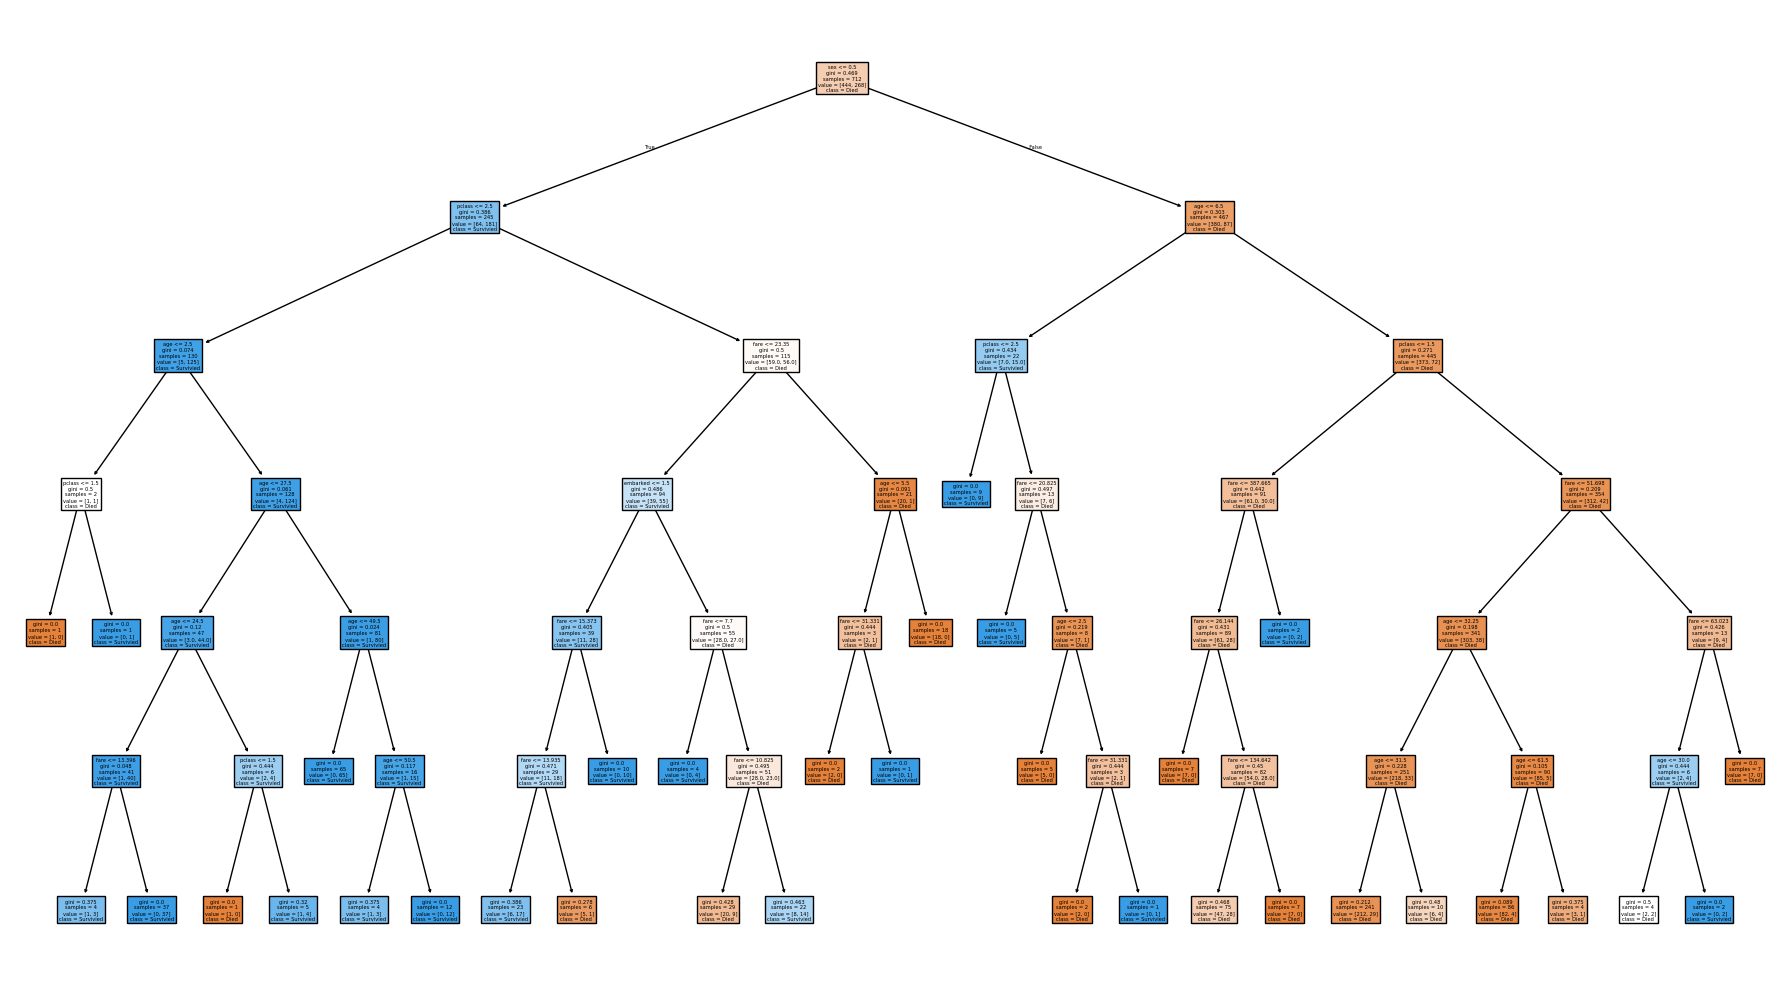

for depth:7  Accuracy:0.7988826815642458
for depth:8  Accuracy:0.7932960893854749
for depth:9  Accuracy:0.7988826815642458
for depth:10  Accuracy:0.7877094972067039


In [20]:
# Decision Tree - with pre pruning
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"for depth:{depth}  Accuracy:{score}")

    if depth==6:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died","Survivied"],
            filled = True
        )
    
        plt.tight_layout()
        plt.show()

for depth:5  Accuracy:0.8212290502793296
for depth:10  Accuracy:0.8324022346368715


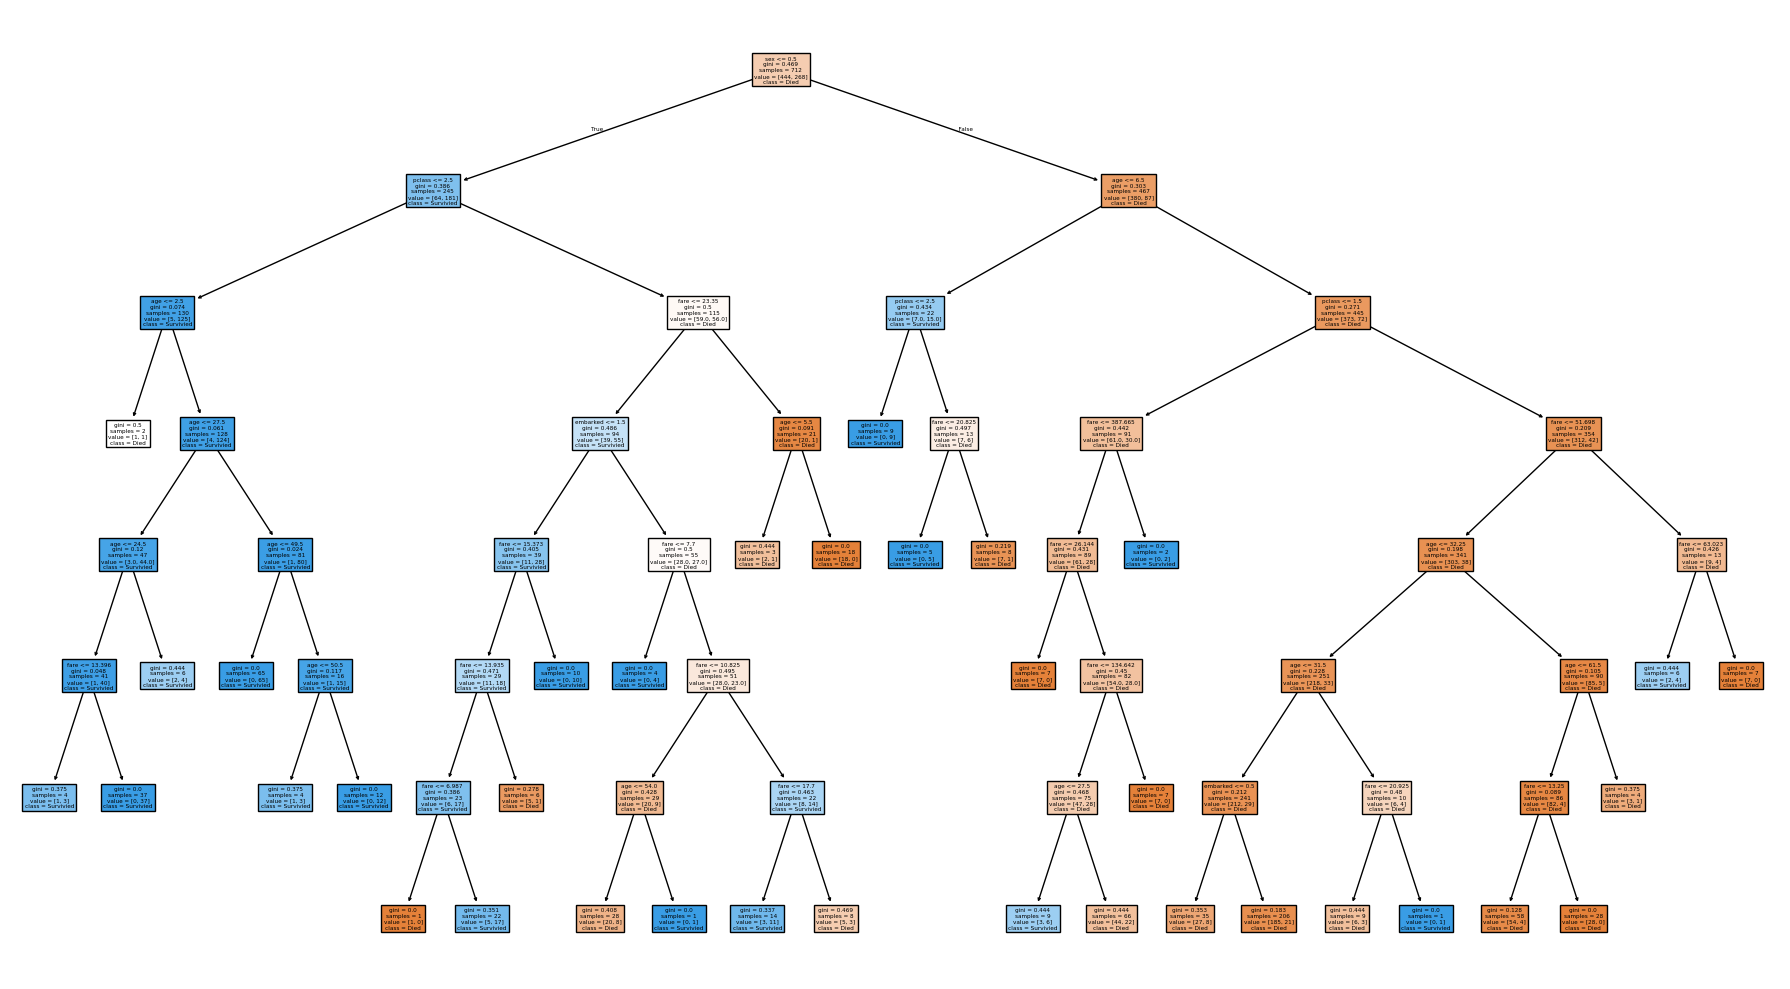

for depth:15  Accuracy:0.8268156424581006
for depth:20  Accuracy:0.8268156424581006
for depth:25  Accuracy:0.8100558659217877
for depth:30  Accuracy:0.7988826815642458


In [16]:
# Decision Tree - with pre pruning
min_samples_splits = [5, 10, 15, 20, 25, 30]

for split in min_samples_splits:
        model = DecisionTreeClassifier(max_depth=7, min_samples_split=split)
        model.fit(X_train, y_train)
        score = model.score(X_test, y_test)
        print(f"for depth:{split}  Accuracy:{score}")

        if split == 10:
            plt.figure(figsize=(18,10))
            plot_tree(
                model,
                feature_names=X.columns,
                class_names=["Died","Survivied"],
                filled = True
            )
        
            plt.tight_layout()
            plt.show()

In [17]:
# Decision Tree - with post-pruning
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [22]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas

array([0.00000000e+00, 0.00000000e+00, 6.68806849e-05, 1.45921494e-04,
       1.84428555e-04, 2.00642055e-04, 2.34082397e-04, 2.34082397e-04,
       3.51123596e-04, 4.68164794e-04, 4.68164794e-04, 5.61797753e-04,
       6.24219725e-04, 6.67991230e-04, 7.02247191e-04, 7.02247191e-04,
       8.19288390e-04, 8.19288390e-04, 8.32292967e-04, 8.42696629e-04,
       8.42696629e-04, 8.42696629e-04, 8.94231048e-04, 8.99610781e-04,
       9.24769963e-04, 9.36329588e-04, 9.36329588e-04, 9.36329588e-04,
       9.88347898e-04, 1.00253471e-03, 1.05337079e-03, 1.07400895e-03,
       1.08038029e-03, 1.11865144e-03, 1.12359551e-03, 1.12359551e-03,
       1.13139825e-03, 1.17041199e-03, 1.18841832e-03, 1.22566125e-03,
       1.22893258e-03, 1.22893258e-03, 1.24361593e-03, 1.24843945e-03,
       1.27565833e-03, 1.30996111e-03, 1.33761370e-03, 1.37044603e-03,
       1.46301498e-03, 1.47927070e-03, 1.51142557e-03, 1.54072312e-03,
       1.56675436e-03, 1.60434338e-03, 1.66892062e-03, 1.76144762e-03,
      

In [25]:
# train model for all alphas

trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)    
    trees.append((model, alpha))

In [26]:
# finding best alpha
best_alpha = 0
best_acc = 0

for model, alpha in trees:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha
print(best_alpha, best_acc)

0.0015407231242023183 0.8379888268156425


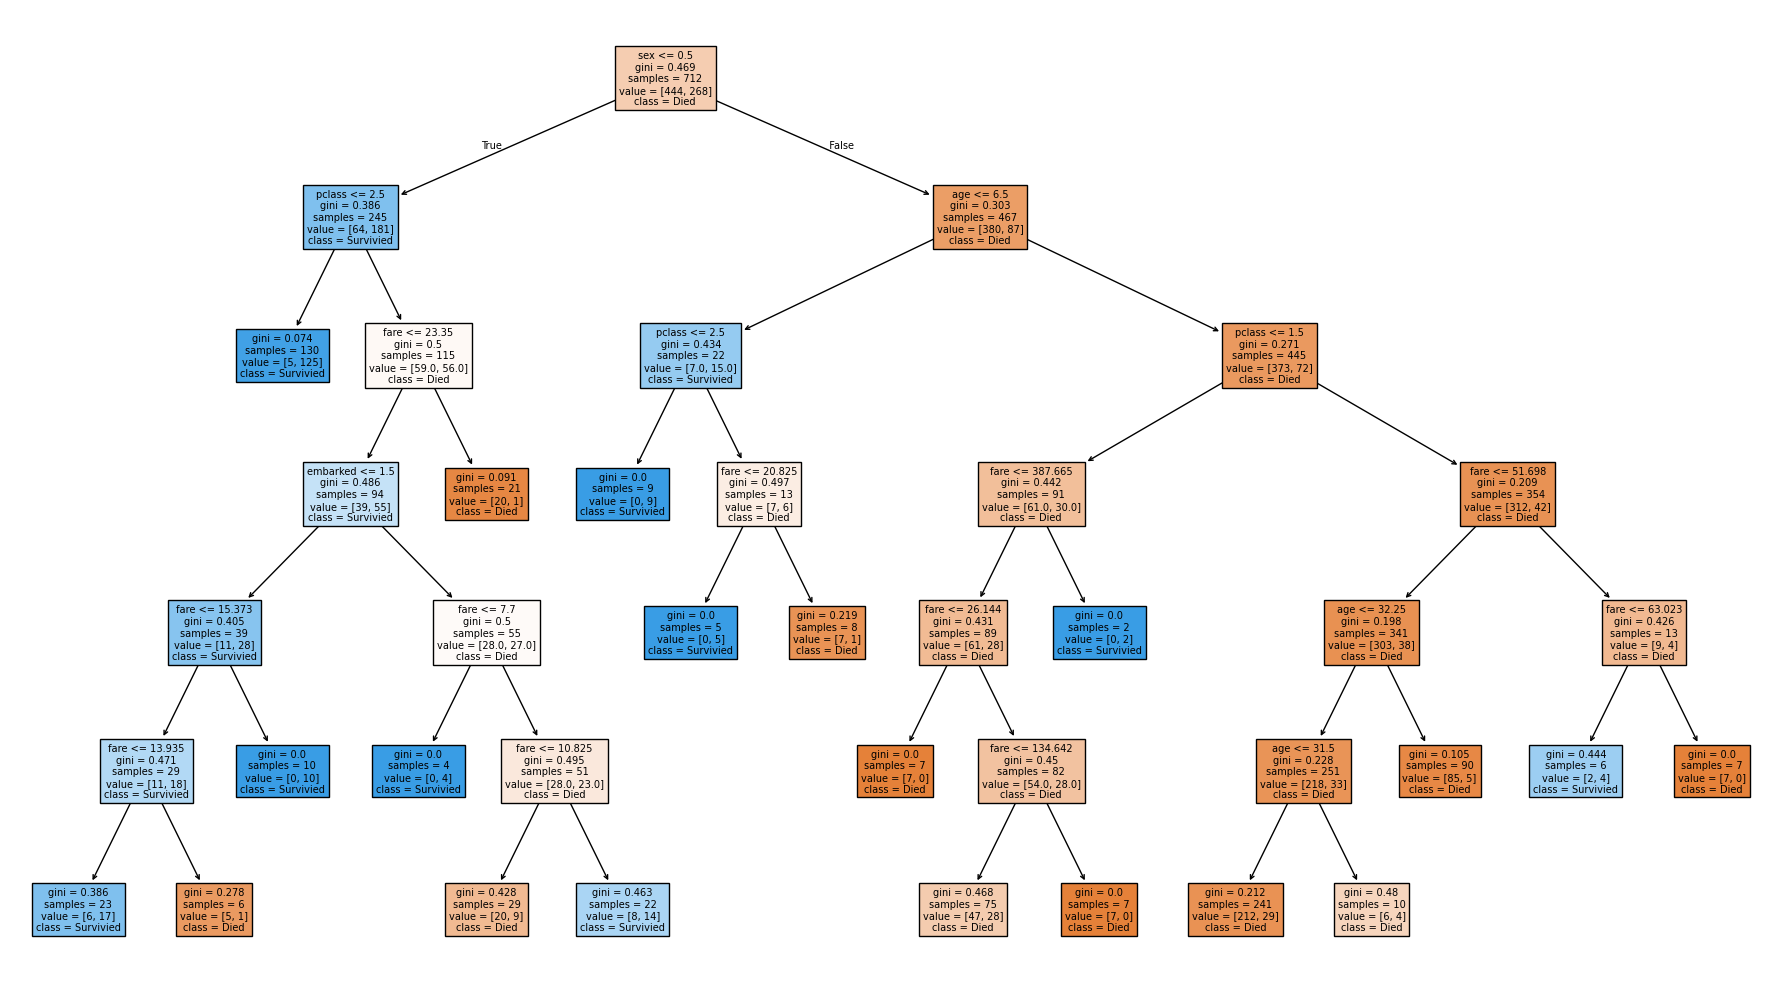

In [29]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha, max_depth=6)
best_model.fit(X_train, y_train)


plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died","Survivied"],
    filled = True
)

plt.tight_layout()
plt.show()

In [30]:
best_model.score(X_test, y_test)

0.8100558659217877

In [31]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train, y_train)
best_model.score(X_test, y_test)

0.8324022346368715